<div align="center">

# 智能体的创建

### 基于 LangChain 的核心组件整理

**技术博文**

</div>

---

在大模型应用开发中，模型本身只负责理解和生成文本，而一个真正可用的智能体（Agent）往往还需要结合消息上下文、工具调用、流程控制以及结构化输出等能力。本文围绕智能体创建过程，整理 5 个核心知识点：模型初始化、消息与提示词模版、工具、中间件、结构化输出。

## 目录

1. 什么是智能体
2. 模型初始化
3. 消息与提示词模版
4. 工具
5. 中间件
6. 结构化输出
7. 创建一个完整智能体
8. 总结

---

## 知识点总览

| 知识点 | 核心作用 | 解决的问题 |
|---|---|---|
| 模型初始化 | 决定底层模型能力 | 智能体由谁来推理 |
| 消息与提示词模版 | 组织上下文与输入结构 | 智能体如何稳定理解问题 |
| 工具 | 连接外部执行能力 | 智能体如何从会说变成会做 |
| 中间件 | 控制模型调用流程 | 智能体如何按规则运行 |
| 结构化输出 | 规范最终结果格式 | 智能体结果如何被程序直接使用 |

> 这张表对应的就是整篇文章的主线。

## 1. 什么是智能体

智能体不是一个单独的模型，而是一套围绕模型构建的执行系统。它通常包括以下几个部分：

- 模型：负责自然语言理解与生成
- 消息：保存系统、用户、助手之间的上下文
- 工具：提供计算、查询、调用接口等外部能力
- 中间件：在模型调用前后加入流程控制逻辑
- 结构化输出：让结果不只是自然语言，而是稳定的数据格式

> 智能体 = 模型 + 上下文 + 工具 + 控制逻辑 + 输出约束

**一句话理解：** 智能体不是一个更大的模型，而是一个围绕模型组织起来的任务执行系统。

## 智能体创建流程图

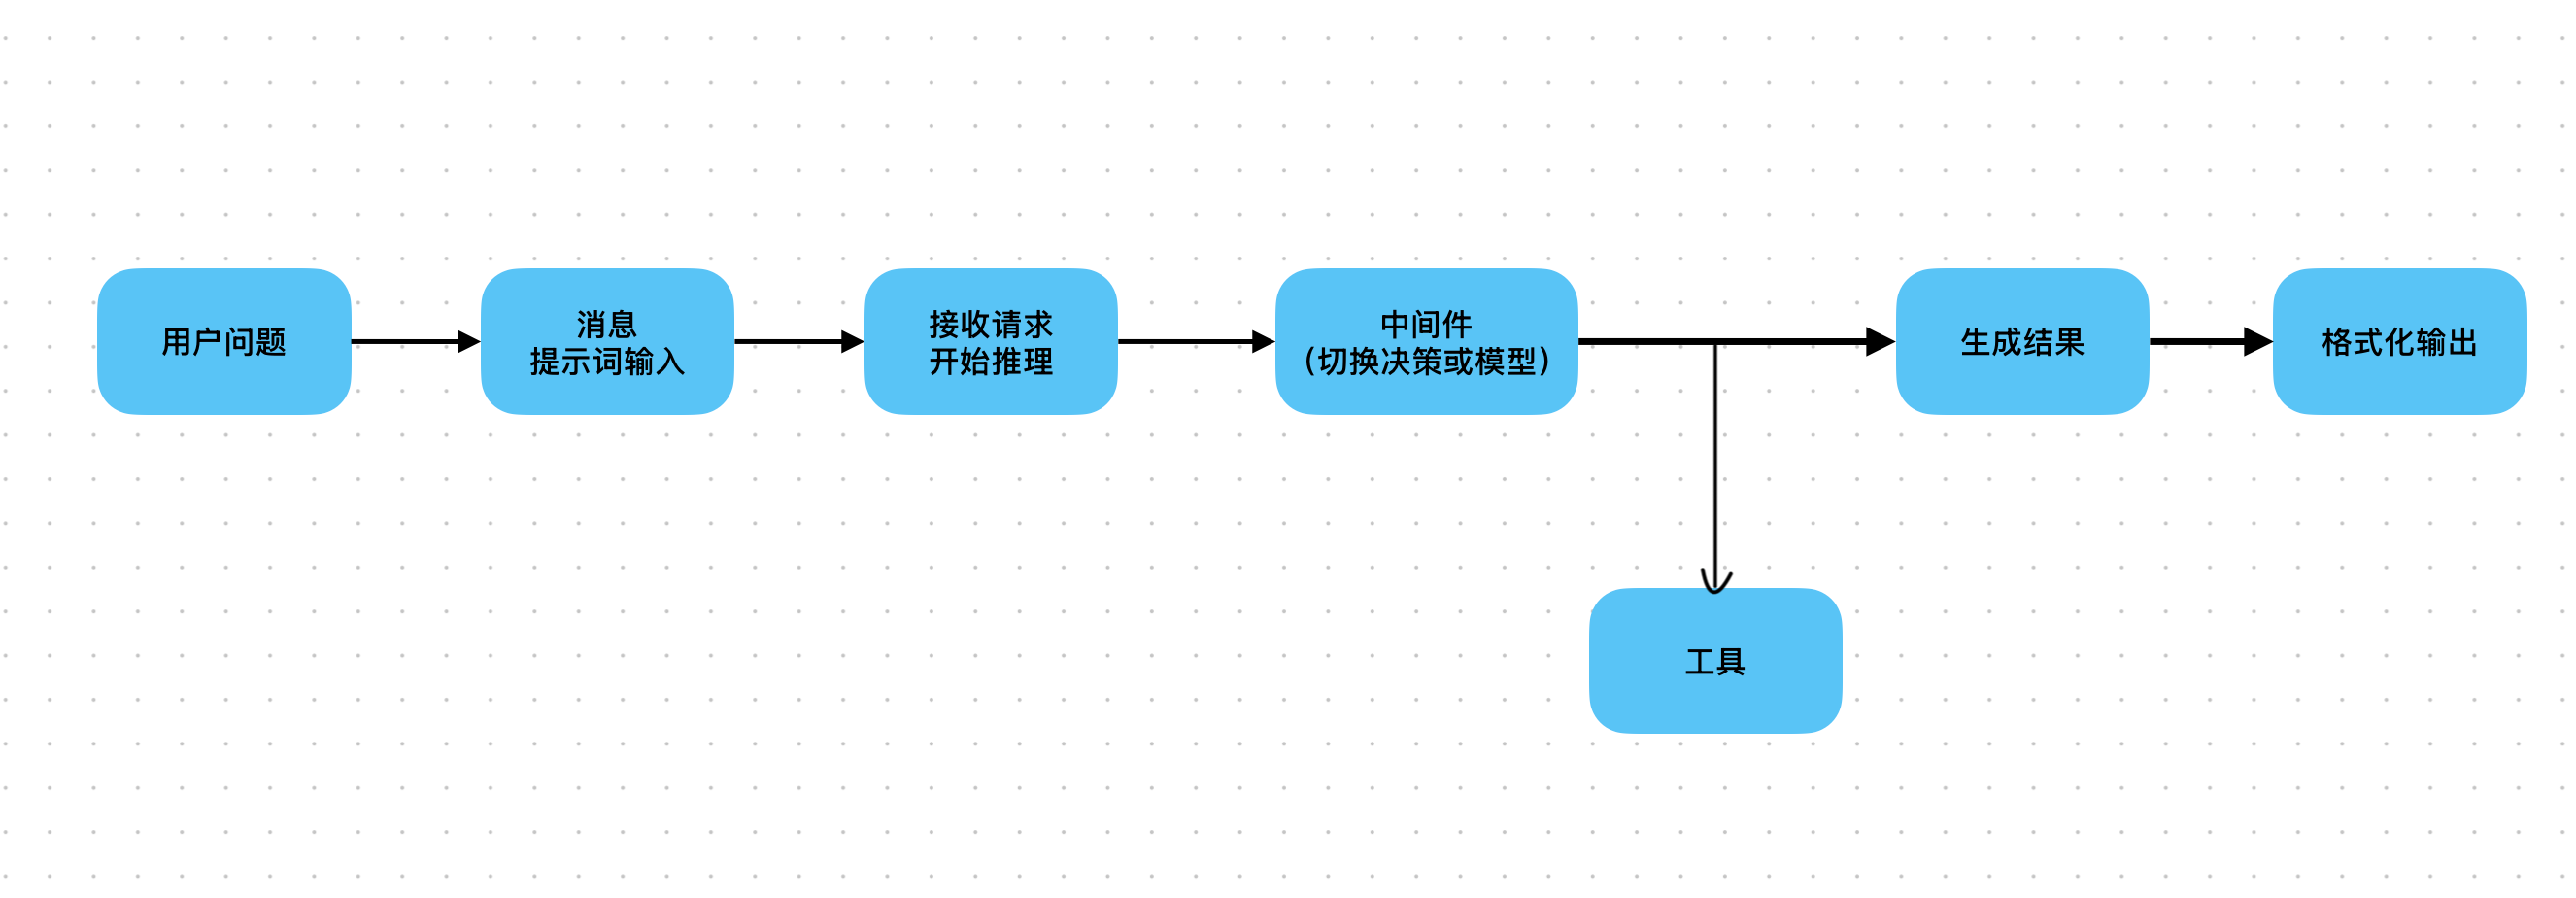

## 2. 1.1 模型初始化

**这一部分要回答的问题是：智能体底层到底由谁来完成推理和生成？**

创建智能体的第一步，是初始化一个可被调度的模型对象。模型初始化决定了智能体的基础能力，例如推理能力、生成稳定性、响应速度和成本。

In [10]:
from langchain.chat_models import init_chat_model

# 初始化聊天模型
model = init_chat_model(
    model="ollama:qwen3.5:4b",  # 指定使用的模型名称，这里使用的是ollama平台上的qwen3:4b模型
    temperature=0.1,          # 设置温度参数，控制输出的随机性，值越小输出越确定
    num_predict=1024          # 设置预测的最大token数量，控制生成内容的长度
)
model

ChatOllama(model='qwen3.5:4b', num_predict=1024, temperature=0.1)

模型初始化中几个常见参数的作用如下：

- `model`：指定底层模型
- `temperature`：控制输出随机性，数值越低越稳定
- `num_predict`：控制单次输出长度

在实际开发中，不同任务适合不同模型。普通问答更关注响应速度和成本，而代码生成或复杂推理更关注模型能力。因此，模型初始化不仅是技术配置问题，也是一种任务策略选择。

> 结论：模型初始化决定了智能体的能力上限，也影响后续工具调用和输出效果。

## 3. 1.2 消息与提示词模版

### 3.1 消息

智能体不是一次性的输入输出系统，而是基于消息流运行的。常见消息类型包括：

- `SystemMessage`：系统指令，用于约束角色和行为边界
- `HumanMessage`：用户输入
- `AIMessage`：模型输出

**可以把消息理解为：智能体的记忆输入格式。**

In [12]:
from langchain.messages import SystemMessage, HumanMessage

messages = [
    SystemMessage(content="你是一个专业的客服助手。"),
    HumanMessage(content="帮我查询订单状态")
]

messages

[SystemMessage(content='你是一个专业的客服助手。', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='帮我查询订单状态', additional_kwargs={}, response_metadata={})]

> 提示：没有消息上下文，智能体往往只能一问一答，难以形成连续对话。

### 3.2 提示词模版

提示词模版用于把固定指令与动态变量组合起来。它的价值在于提高提示词的复用性和可维护性，避免在代码中反复拼接字符串。

如果说消息解决的是内容怎么传，那么提示词模版解决的是内容怎么组织得更规范。

In [13]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个{role}，负责回答用户问题。"),
    ("human", "{query}")
])

prompt.invoke({
    "role": "数据分析助手",
    "query": "请解释什么是智能体"
})

ChatPromptValue(messages=[SystemMessage(content='你是一个数据分析助手，负责回答用户问题。', additional_kwargs={}, response_metadata={}), HumanMessage(content='请解释什么是智能体', additional_kwargs={}, response_metadata={})])

> 结论：消息决定上下文连续性，提示词模版决定输入规范性。

## 4. 工具

大模型擅长自然语言生成，但它本身并不能直接访问外部世界。比如，它不能真正查询数据库、不能真实调用业务接口、也不能可靠执行复杂计算。

工具的作用，就是把这些外部能力封装成函数，再交给模型使用。模型负责决定什么时候调用工具，工具负责完成具体任务。

**工具的意义在于：把大模型能理解语言，扩展成大模型能完成动作。**

In [14]:
from langchain.tools import tool

@tool
def calculator(op: str, p1: float, p2: float) -> float:
    """执行加减乘除运算。"""
    if op == "+":
        return p1 + p2
    if op == "-":
        return p1 - p2
    if op == "*":
        return p1 * p2
    if op == "/":
        return p1 / p2
    raise ValueError("不支持的运算符")

calculator

StructuredTool(name='calculator', description='执行加减乘除运算。', args_schema=<class 'langchain_core.utils.pydantic.calculator'>, func=<function calculator at 0x128e02f20>)

In [15]:
model_with_tools = model.bind_tools([calculator])

response = model_with_tools.invoke("56与67的积是多少？")
response

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-04-09T12:22:19.364081Z', 'done': True, 'done_reason': 'stop', 'total_duration': 43300405834, 'load_duration': 7257298209, 'prompt_eval_count': 304, 'prompt_eval_duration': 4793714875, 'eval_count': 116, 'eval_duration': 30950302079, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019d7230-d4bc-7e42-94f6-88a07ae57ffa-0', tool_calls=[{'name': 'calculator', 'args': {'op': '乘', 'p1': 56, 'p2': 67}, 'id': 'cc1636b1-9cac-4ae7-a806-1bfa8193633a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 304, 'output_tokens': 116, 'total_tokens': 420})

> 结论：工具让智能体从回答问题升级为执行任务。

## 5. 中间件

中间件可以理解为智能体运行过程中的拦截器。它允许我们在模型调用之前或之后插入额外逻辑，例如：按任务类型切换模型、记录日志、控制权限、统计耗时与成本。

**中间件关注的不是回答什么，而是整个调用过程怎么跑。**

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

model_4b = init_chat_model(model="ollama:qwen3:4b", temperature=0.1)
model_9b = init_chat_model(model="ollama:qwen3.5:9b", temperature=0.7)

@wrap_model_call  # 装饰器，用于包装模型调用函数
def switch_model(request: ModelRequest, handler) -> ModelResponse:
    # 检查请求消息的第一条内容是否以"#"开头
    if request.messages[0].content.startswith("#"):
        # 如果以"#"开头，则使用model_9b模型处理请求
        return handler(request.override(model=model_9b))
    # 否则使用model_4b模型处理请求
    return handler(request.override(model=model_4b))

上面的逻辑表示：如果用户输入以 `#` 开头，则切换到更强的模型；否则继续使用默认模型。这说明一个智能体并不一定只依赖单一模型，而是可以根据任务动态调整底层能力。

> 结论：中间件本质上是在给智能体增加流程编排能力。

## 6. 结构化输出

如果智能体只输出自然语言，虽然人能够读懂，但程序不容易进一步处理。很多实际场景更需要稳定的数据格式，例如联系人信息、订单字段、分类结果等。

**结构化输出的目标不是让回答更好看，而是让结果更容易被程序继续使用。**

In [17]:
from pydantic import BaseModel, Field

class ContactInfo(BaseModel):
    name: str = Field(description="姓名")
    email: str = Field(description="电子邮箱")
    phone: str = Field(description="电话号码")

ContactInfo.model_json_schema()

{'properties': {'name': {'description': '姓名',
   'title': 'Name',
   'type': 'string'},
  'email': {'description': '电子邮箱', 'title': 'Email', 'type': 'string'},
  'phone': {'description': '电话号码', 'title': 'Phone', 'type': 'string'}},
 'required': ['name', 'email', 'phone'],
 'title': 'ContactInfo',
 'type': 'object'}

把这个数据结构作为 `response_format` 传入智能体后，模型最终输出的就不再只是自由文本，而是符合特定字段约束的结构化结果。

> 结论：结构化输出让智能体结果从可读变成可用。

## 7. 创建一个完整智能体

前面几个知识点可以组合成一个完整的智能体。下面给出一个简化示例，这个示例把前文的 5 个要素放到同一个流程里，便于形成整体理解。

In [ ]:
from langchain.agents import create_agent
from langchain.messages import SystemMessage
from pydantic import BaseModel, Field
import requests
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from pydantic import BaseModel, Field

weather_model = init_chat_model(model="ollama:qwen3.5:4b", temperature=0.1)

class WeatherResult(BaseModel):
    city: str = Field(description="城市")
    weather: str = Field(description="天气信息")


def get_coordinates(city_name: str):
    """通过城市名获取经纬度（使用Open-Meteo地理编码API）"""
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city_name}&count=1&language=zh&format=json"
    try:
        response = requests.get(geo_url, timeout=10)
        data = response.json()
        if data.get('results'):
            location = data['results'][0]
            return location['latitude'], location['longitude'], location['name']
        else:
            return None, None, None
    except Exception as e:
        print(f"地理编码查询失败: {e}")
        return None, None, None

@tool
def get_weather(location: str) -> str:
    """
    获取指定位置的天气信息。
    
    参数:
    location (str): 需要查询天气的地理位置，例如 "北京" 或 "New York"。
    
    返回:
    str: 指定位置的天气信息。
    """
    # 1. 获取城市坐标
    lat, lon, city_name = get_coordinates(location)
    if lat is None:
        return f"未找到城市: {location}，请检查城市名称是否正确。"
    
    # 2. 构建天气API请求
    weather_url = (
        f"https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}&longitude={lon}"
        f"&current_weather=true"
        f"&hourly=temperature_2m,relativehumidity_2m,windspeed_10m"
        f"&timezone=auto"
    )
    
    try:
        # 3. 发送请求
        response = requests.get(weather_url, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        # 4. 解析天气数据
        current = data.get('current_weather', {})
        temp = current.get('temperature')
        wind_speed = current.get('windspeed')
        
        # 获取湿度数据
        hourly = data.get('hourly', {})
        humidity = None
        if hourly.get('relativehumidity_2m'):
            humidity = hourly['relativehumidity_2m'][0]
        
        # 5. 格式化返回结果
        weather_desc = "晴朗" if current.get('weathercode') == 0 else "多云或有雨"
        result = f"{city_name} 当前天气：{weather_desc}，温度 {temp}°C，风速 {wind_speed} km/h"
        if humidity:
            result += f"，湿度 {humidity}%"
        
        return result + "。"
    except requests.exceptions.RequestException as e:
        return f"网络请求错误：{e}"
    except Exception as e:
        return f"处理数据时出错：{e}"


agent = create_agent(
    model=weather_model,
    tools=[get_weather],
    middleware=[],
    system_prompt=SystemMessage(content="你是一个天气查询助手。"),
    response_format=WeatherResult
)

result = agent.invoke({
    "messages": [
        {"role": "user", "content": "北京天气怎么样？"}
    ]
})
result

从这个示例可以看到，智能体创建不是单一步骤，而是多个组件的组合：初始化模型、组织上下文、注册工具、控制流程、规范输出。也正因为如此，创建智能体更像是在设计一个系统，而不只是调用一个模型接口。

## 8. 总结


通过本文可以看出，智能体的创建并不是简单地调用一个 API，而是围绕模型构建一套可执行的任务系统。

- 模型初始化：决定智能体的基础推理与生成能力
- 消息与提示词模版：决定上下文如何组织
- 工具：决定智能体可以执行哪些外部能力
- 中间件：决定执行过程如何被控制和优化
- 结构化输出：决定结果是否能稳定落地到程序中

因此，智能体不是一个更强的模型，而是一个围绕模型设计出来的任务执行框架。只有把这些组件协同起来，才能真正实现从聊天到完成任务的能力升级。

---

## 小结论

通过对智能体创建过程的整理，可以得到一个清晰结论：智能体的创建不是单点技术，而是多个组件协同工作的结果。模型提供智能基础，消息和提示词提供上下文组织能力，工具负责连接外部能力，中间件负责流程控制，结构化输出负责结果落地。只有把这 5 个知识点组合起来，智能体才真正具备完成任务的能力。